# Parking Lot IP Scaling Tests with Queueing and FIFO Entry

This notebook is the scaling version of the improved GIF model.

It compares three assignment strategies:

1. `random`
2. `nearest`
3. `furthest`

For each assignment method, the model:

1. Builds a parameterized parking-lot graph.
2. Generates one car per parking spot.
3. Assigns cars to spots using the selected method.
4. Computes fixed NetworkX shortest paths.
5. Solves an IP that schedules movement along those fixed paths.
6. Enforces physical edge capacity, so opposite directions on the same aisle share capacity.
7. Enforces node capacity, so cars queue instead of occupying the same intersection.
8. Enforces parking blocking, so a parking car blocks its adjacent aisle/intersection node.
9. Enforces FIFO entrance order, so cars from the same entrance enter in arrival order.
10. Minimizes makespan.

Important runtime behavior:

- Each full instance gets a cutoff controlled by `INSTANCE_TIME_LIMIT_SECONDS`.
- The cutoff includes graph building, car generation, shortest paths, IP construction, and IP solve.
- The default cutoff is **600 seconds = 10 minutes**.
- If a method hits the cutoff for a row value, that method stops and does not try larger row values.
- Timed-out/cutoff rows are saved in `results_df`, but they are **excluded from every plot**.


In [1]:
import time
import random
from collections import defaultdict

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

try:
    import gurobipy as gp
    from gurobipy import GRB
except ImportError as exc:
    raise ImportError(
        "This notebook requires gurobipy. Run it in the environment where your Gurobi license is configured."
    ) from exc


## 1. Parking-lot graph construction

In [2]:
def build_parking_lot_graph(
    num_rows,
    row_spacing=3.0,
    col_spacing=8.0,
    spot_offset=2.0,
    middle_spot_offset=1.2,
    top_bottom_capacity=3,
    normal_aisle_capacity=1,
    top_bottom_travel_time=3,
    normal_aisle_travel_time=1,
    parking_duration=3,
):
    if num_rows < 3:
        raise ValueError("num_rows must be at least 3.")

    expected_num_spots = (num_rows - 2) * 4

    G = nx.DiGraph()
    pos = {}

    left_col_x = 0
    right_col_x = col_spacing

    for r in range(num_rows):
        y = -r * row_spacing
        left_node = f"L{r}"
        right_node = f"R{r}"

        pos[left_node] = (left_col_x, y)
        pos[right_node] = (right_col_x, y)

        G.add_node(left_node, kind="intersection", node_capacity=1)
        G.add_node(right_node, kind="intersection", node_capacity=1)

        # Top and bottom cross-aisles connect the left and right aisles.
        if r == 0 or r == num_rows - 1:
            for u, v in [(left_node, right_node), (right_node, left_node)]:
                G.add_edge(
                    u,
                    v,
                    travel_time=top_bottom_travel_time,
                    capacity=top_bottom_capacity,
                    edge_type="aisle",
                )

    # Vertical one-lane aisles.
    for r in range(num_rows - 1):
        for u, v in [
            (f"L{r}", f"L{r+1}"),
            (f"L{r+1}", f"L{r}"),
            (f"R{r}", f"R{r+1}"),
            (f"R{r+1}", f"R{r}"),
        ]:
            G.add_edge(
                u,
                v,
                travel_time=normal_aisle_travel_time,
                capacity=normal_aisle_capacity,
                edge_type="aisle",
            )

    entrances = ["E1", "E2"]

    pos["E1"] = (left_col_x, row_spacing)
    pos["E2"] = (right_col_x, -num_rows * row_spacing)

    # Entrances are not node-capacity constrained. They act like external queues.
    G.add_node("E1", kind="entrance")
    G.add_node("E2", kind="entrance")

    G.add_edge("E1", "L0", travel_time=1, capacity=top_bottom_capacity, edge_type="aisle")
    G.add_edge("E2", f"R{num_rows - 1}", travel_time=1, capacity=top_bottom_capacity, edge_type="aisle")

    spot_count = 1

    for r in range(1, num_rows - 1):
        y = -r * row_spacing

        spot_specs = [
            (f"L{r}", left_col_x - spot_offset, y),
            (f"L{r}", left_col_x + spot_offset, y + middle_spot_offset),
            (f"R{r}", right_col_x - spot_offset, y - middle_spot_offset),
            (f"R{r}", right_col_x + spot_offset, y),
        ]

        for aisle_node, x_pos, y_pos in spot_specs:
            spot = f"S{spot_count}"
            spot_count += 1

            pos[spot] = (x_pos, y_pos)
            G.add_node(spot, kind="spot")

            # Entering the spot is the parking maneuver and takes several seconds.
            G.add_edge(
                aisle_node,
                spot,
                travel_time=parking_duration,
                capacity=1,
                edge_type="parking",
            )

            # Reverse edge is only present so the graph remains visually complete.
            # Cars never use it in the fixed entrance-to-spot paths.
            G.add_edge(
                spot,
                aisle_node,
                travel_time=1,
                capacity=1,
                edge_type="spot",
            )

    parking_spots = [
        node for node, data in G.nodes(data=True)
        if data.get("kind") == "spot"
    ]

    if len(parking_spots) != expected_num_spots:
        raise ValueError(
            f"Expected {expected_num_spots} spots, generated {len(parking_spots)}."
        )

    return G, pos, parking_spots, entrances


## 2. Arrival generation and assignment methods

Nearest and furthest assignment are entrance-relative and prefer the car's own aisle side first. Random assignment is unchanged.

In [3]:
def generate_poisson_arrival_times(
    num_cars,
    total_time=30,
    base_rate=0.40,
    peak_rate=2.20,
    peak_time=18,
    rng=None,
):
    if rng is None:
        rng = np.random.default_rng()

    arrival_times = []

    for t in range(total_time):
        if t <= peak_time:
            rate = base_rate + (peak_rate - base_rate) * (t / peak_time)
        else:
            rate = peak_rate * max(
                0.15,
                1 - (t - peak_time) / max(1, total_time - peak_time),
            )

        for _ in range(rng.poisson(rate)):
            arrival_times.append(t)

        if len(arrival_times) >= num_cars:
            break

    if len(arrival_times) == 0:
        arrival_times.append(0)

    while len(arrival_times) < num_cars:
        arrival_times.append(arrival_times[-1] + rng.poisson(1) + 1)

    return arrival_times[:num_cars]


def car_number(car):
    return int(car["name"].split()[-1])


def spot_number(spot):
    return int(spot[1:])


def spot_side(spot):
    """Left-side spots are positions 1-2 in each row; right-side spots are positions 3-4."""
    position_in_row = (spot_number(spot) - 1) % 4
    return "L" if position_in_row in [0, 1] else "R"


def car_side(car):
    if car["start"] == "E1":
        return "L"
    if car["start"] == "E2":
        return "R"
    raise ValueError(f"Unknown car entrance: {car['start']}")


def cars_in_arrival_order(cars):
    """Stable physical order used by greedy assignments and entrance FIFO constraints."""
    return sorted(cars, key=lambda car: (car["start_time"], car_number(car)))


def assignment_distance(G, entrance, spot):
    """Shortest-path travel time from this car's entrance to this available spot."""
    return nx.shortest_path_length(G, source=entrance, target=spot, weight="travel_time")


def assignment_tie_breaker(spot):
    """Deterministic tie-breaker so GIFs are reproducible."""
    return spot_number(spot)


def same_side_available_spots(car, available_spots):
    """Prefer spots on the car's own aisle. Fall back only if that side is full."""
    preferred_side = car_side(car)
    same_side = [spot for spot in available_spots if spot_side(spot) == preferred_side]
    return same_side if same_side else list(available_spots)


def assign_random_spots(cars, parking_spots, random_state, G=None):
    chosen_spots = random_state.sample(sorted(parking_spots, key=spot_number), len(cars))

    for car, spot in zip(cars, chosen_spots):
        car["spot"] = spot

    return cars


def assign_nearest_spots(cars, parking_spots, random_state=None, G=None):
    """Greedy nearest-available same-aisle assignment from each car's own entrance."""
    if G is None:
        raise ValueError("G is required for distance-based nearest assignment.")

    available_spots = set(parking_spots)

    for car in cars_in_arrival_order(cars):
        candidate_spots = same_side_available_spots(car, available_spots)
        best_spot = min(
            candidate_spots,
            key=lambda spot: (
                assignment_distance(G, car["start"], spot),
                assignment_tie_breaker(spot),
            ),
        )
        car["spot"] = best_spot
        available_spots.remove(best_spot)

    return cars


def assign_furthest_spots(cars, parking_spots, random_state=None, G=None):
    """Greedy furthest-available same-aisle assignment from each car's own entrance."""
    if G is None:
        raise ValueError("G is required for distance-based furthest assignment.")

    available_spots = set(parking_spots)

    for car in cars_in_arrival_order(cars):
        candidate_spots = same_side_available_spots(car, available_spots)
        best_spot = max(
            candidate_spots,
            key=lambda spot: (
                assignment_distance(G, car["start"], spot),
                -assignment_tie_breaker(spot),
            ),
        )
        car["spot"] = best_spot
        available_spots.remove(best_spot)

    return cars


ASSIGNMENT_FUNCTIONS = {
    "random": assign_random_spots,
    "nearest": assign_nearest_spots,
    "furthest": assign_furthest_spots,
}


def create_cars_for_lot(
    G,
    parking_spots,
    entrances,
    seed=42,
    assignment_method="random",
):
    rng = np.random.default_rng(seed)
    random_state = random.Random(seed)

    num_cars = len(parking_spots)
    arrival_times = generate_poisson_arrival_times(num_cars, rng=rng)

    cars = []

    for i in range(num_cars):
        cars.append({
            "name": f"car {i + 1}",
            "start": entrances[i % len(entrances)],
            "start_time": arrival_times[i],
            "spot": None,
            "path": None,
            "path_edges": None,
            "travel_time": None,
        })

    if assignment_method not in ASSIGNMENT_FUNCTIONS:
        raise ValueError(f"Unknown assignment method: {assignment_method}")

    cars = ASSIGNMENT_FUNCTIONS[assignment_method](
        cars=cars,
        parking_spots=parking_spots,
        random_state=random_state,
        G=G,
    )

    for car in cars:
        if not nx.has_path(G, car["start"], car["spot"]):
            raise ValueError(f"No path from {car['start']} to {car['spot']}.")

        car["path"] = nx.shortest_path(
            G,
            source=car["start"],
            target=car["spot"],
            weight="travel_time",
        )

        car["path_edges"] = list(zip(car["path"][:-1], car["path"][1:]))

        car["travel_time"] = nx.shortest_path_length(
            G,
            source=car["start"],
            target=car["spot"],
            weight="travel_time",
        )

    return cars


## 3. IP helper functions

In [4]:
def edge_duration(G, edge):
    u, v = edge
    return int(G[u][v].get("travel_time", 1))


def is_parking_edge(G, edge):
    u, v = edge
    return G[u][v].get("edge_type") == "parking"


def is_capacity_constrained_node(G, node):
    return G.nodes[node].get("kind") == "intersection"


def physical_edge_key(edge):
    """Group opposite directions of the same physical segment together."""
    u, v = edge
    return tuple(sorted((u, v)))


def physical_edge_capacity(G, physical_key):
    """Use the largest listed directed capacity for the physical segment."""
    u, v = physical_key
    capacities = []
    if G.has_edge(u, v):
        capacities.append(G[u][v].get("capacity", 1))
    if G.has_edge(v, u):
        capacities.append(G[v][u].get("capacity", 1))
    return max(capacities) if capacities else 1


def parking_aisle_node(G, edge):
    u, v = edge
    return u if is_parking_edge(G, edge) else None


## 4. Fixed-path IP solver with node queues and FIFO entrances

The solver is the improved model from the GIF notebook, without animation code.

In [5]:
def timeout_result(status, elapsed_time, model=None, T=np.nan):
    return {
        "status_code": None,
        "status": status,
        "solver_runtime": 0.0,
        "wall_runtime": elapsed_time,
        "num_vars": np.nan if model is None else model.NumVars,
        "num_constraints": np.nan if model is None else model.NumConstrs,
        "time_horizon": T,
        "has_solution": False,
        "makespan": np.nan,
        "avg_wait_time": np.nan,
        "total_wait_time": np.nan,
        "max_wait_time": np.nan,
        "mip_gap": np.nan,
    }


def solve_fixed_path_ip(
    G,
    cars,
    instance_start_time,
    instance_time_limit_seconds=600,
    mip_gap=None,
    output_flag=0,
):
    def elapsed():
        return time.time() - instance_start_time

    def remaining_time():
        return instance_time_limit_seconds - elapsed()

    def timed_out():
        return remaining_time() <= 0

    if timed_out():
        return timeout_result("INSTANCE_TIMEOUT", elapsed())

    num_cars = len(cars)
    max_arrival_time = max(car["start_time"] for car in cars)

    max_path_duration = max(
        sum(edge_duration(G, edge) for edge in car["path_edges"])
        for car in cars
    )

    max_parking_duration = max(
        edge_duration(G, edge)
        for car in cars
        for edge in car["path_edges"]
        if is_parking_edge(G, edge)
    )

    # Conservative horizon: enough time for every car to park one after another,
    # plus path travel and slack.
    T = max_arrival_time + (num_cars * max_parking_duration) + max_path_duration + 30

    model = gp.Model("fixed_path_ip_with_node_queues")
    model.Params.OutputFlag = output_flag

    if mip_gap is not None:
        model.Params.MIPGap = mip_gap

    x = {}
    y = {}

    # x[c,k,t] = car c starts edge k at time t.
    for c, car in enumerate(cars):
        if timed_out():
            return timeout_result("INSTANCE_TIMEOUT", elapsed(), model, T)

        for k, edge in enumerate(car["path_edges"]):
            dur = edge_duration(G, edge)
            for t in range(T - dur + 1):
                x[c, k, t] = model.addVar(
                    vtype=GRB.BINARY,
                    name=f"x_car{c}_edge{k}_time{t}",
                )

    # y[c,i,t] = car c is at path node i at integer time t.
    for c, car in enumerate(cars):
        for i, node in enumerate(car["path"]):
            for t in range(T + 1):
                y[c, i, t] = model.addVar(
                    vtype=GRB.BINARY,
                    name=f"y_car{c}_node{i}_time{t}",
                )

    finish_time = {
        c: model.addVar(vtype=GRB.INTEGER, lb=0, ub=T, name=f"finish_time_car{c}")
        for c in range(num_cars)
    }

    makespan = model.addVar(vtype=GRB.INTEGER, lb=0, ub=T, name="makespan")
    model.update()

    # Constraint 1: each path edge is traversed exactly once.
    for c, car in enumerate(cars):
        for k, edge in enumerate(car["path_edges"]):
            dur = edge_duration(G, edge)
            model.addConstr(
                gp.quicksum(x[c, k, t] for t in range(T - dur + 1)) == 1,
                name=f"car{c}_edge{k}_once",
            )

    # Constraint 2: path-node flow conservation.
    # Cars enter their entrance node at start_time, then either wait or move forward.
    for c, car in enumerate(cars):
        K = len(car["path_edges"])
        arrival_time = car["start_time"]

        for i, node in enumerate(car["path"]):
            initial_value = 1 if (i == 0 and arrival_time == 0) else 0
            model.addConstr(y[c, i, 0] == initial_value, name=f"initial_car{c}_node{i}")

        for t in range(T):
            for i, node in enumerate(car["path"]):
                depart = 0
                if i < K:
                    edge = car["path_edges"][i]
                    dur = edge_duration(G, edge)
                    if t <= T - dur:
                        depart = x[c, i, t]

                arrive = 0
                if i > 0:
                    prev_edge = car["path_edges"][i - 1]
                    prev_dur = edge_duration(G, prev_edge)
                    start_time_for_arrival = t + 1 - prev_dur
                    if 0 <= start_time_for_arrival <= T - prev_dur:
                        arrive = x[c, i - 1, start_time_for_arrival]

                external_arrival = 1 if (i == 0 and t + 1 == arrival_time) else 0

                model.addConstr(
                    y[c, i, t + 1] == y[c, i, t] - depart + arrive + external_arrival,
                    name=f"flow_car{c}_node{i}_time{t}",
                )

    # Constraint 3: a car can only start an edge if it is currently at that edge's start node.
    for c, car in enumerate(cars):
        for k, edge in enumerate(car["path_edges"]):
            dur = edge_duration(G, edge)
            for t in range(T - dur + 1):
                model.addConstr(
                    x[c, k, t] <= y[c, k, t],
                    name=f"depart_only_if_present_car{c}_edge{k}_time{t}",
                )

    # Constraint 4: physical aisle/parking segment capacities.
    # Opposite directions of the same physical aisle segment share capacity, which prevents passing.
    active_by_physical_edge_time = defaultdict(list)

    for c, car in enumerate(cars):
        for k, edge in enumerate(car["path_edges"]):
            dur = edge_duration(G, edge)
            key = physical_edge_key(edge)
            for start_t in range(T - dur + 1):
                for tau in range(start_t, start_t + dur):
                    active_by_physical_edge_time[key, tau].append(x[c, k, start_t])

    for (physical_key, tau), active_terms in active_by_physical_edge_time.items():
        if timed_out():
            return timeout_result("INSTANCE_TIMEOUT", elapsed(), model, T)

        model.addConstr(
            gp.quicksum(active_terms) <= physical_edge_capacity(G, physical_key),
            name=f"physical_edge_capacity_{physical_key[0]}_{physical_key[1]}_time{tau}",
        )

    # Constraint 5: node capacity and parking blocking.
    # y terms make cars wait in queues at nodes. Parking terms keep the adjacent aisle blocked
    # while a car is pulling into its spot.
    y_terms_by_node_time = defaultdict(list)
    parking_block_terms_by_node_time = defaultdict(list)

    for c, car in enumerate(cars):
        for i, node in enumerate(car["path"]):
            if is_capacity_constrained_node(G, node):
                for tau in range(T + 1):
                    y_terms_by_node_time[node, tau].append(y[c, i, tau])

        for k, edge in enumerate(car["path_edges"]):
            if not is_parking_edge(G, edge):
                continue

            aisle_node = parking_aisle_node(G, edge)
            dur = edge_duration(G, edge)

            for start_t in range(T - dur + 1):
                # At start_t, the car is already counted by y at the aisle node.
                # For the remaining parking seconds, the maneuver continues to block the aisle node.
                for tau in range(start_t + 1, start_t + dur):
                    parking_block_terms_by_node_time[aisle_node, tau].append(x[c, k, start_t])

    constrained_nodes = [
        node for node, data in G.nodes(data=True)
        if is_capacity_constrained_node(G, node)
    ]

    for node in constrained_nodes:
        node_capacity = G.nodes[node].get("node_capacity", 1)

        for tau in range(T + 1):
            if timed_out():
                return timeout_result("INSTANCE_TIMEOUT", elapsed(), model, T)

            terms = []
            terms.extend(y_terms_by_node_time.get((node, tau), []))
            terms.extend(parking_block_terms_by_node_time.get((node, tau), []))

            if terms:
                model.addConstr(
                    gp.quicksum(terms) <= node_capacity,
                    name=f"node_capacity_{node}_time{tau}",
                )

    # Constraint 6: FIFO entrance order.
    # For each entrance, earlier-arriving cars must begin their first movement no later
    # than later-arriving cars. Ties are broken by car number. This prevents Gurobi from
    # improving the objective by letting car 3 enter before car 1 at the same entrance.
    first_start_expr = {}

    for c, car in enumerate(cars):
        first_edge = car["path_edges"][0]
        first_duration = edge_duration(G, first_edge)
        first_start_expr[c] = gp.quicksum(
            t * x[c, 0, t]
            for t in range(T - first_duration + 1)
        )

    cars_by_entrance = defaultdict(list)
    for c, car in enumerate(cars):
        cars_by_entrance[car["start"]].append((c, car))

    for entrance, entrance_cars in cars_by_entrance.items():
        ordered = sorted(
            entrance_cars,
            key=lambda item: (item[1]["start_time"], car_number(item[1])),
        )

        for earlier, later in zip(ordered, ordered[1:]):
            earlier_c, earlier_car = earlier
            later_c, later_car = later
            model.addConstr(
                first_start_expr[earlier_c] <= first_start_expr[later_c],
                name=f"fifo_{entrance}_car{earlier_c}_before_car{later_c}",
            )

    # Constraint 7: finish time definition.
    for c, car in enumerate(cars):
        last_step = len(car["path_edges"]) - 1
        final_edge = car["path_edges"][last_step]
        final_duration = edge_duration(G, final_edge)

        final_start = gp.quicksum(
            t * x[c, last_step, t]
            for t in range(T - final_duration + 1)
        )

        model.addConstr(
            finish_time[c] == final_start + final_duration,
            name=f"finish_time_def_car{c}",
        )

    # Constraint 8: makespan definition.
    for c in range(num_cars):
        model.addConstr(makespan >= finish_time[c], name=f"makespan_after_car{c}")

    model.setObjective(makespan, GRB.MINIMIZE)

    model.Params.TimeLimit = max(1.0, remaining_time())
    model.optimize()

    status_text = {
        GRB.OPTIMAL: "OPTIMAL",
        GRB.TIME_LIMIT: "TIME_LIMIT",
        GRB.INFEASIBLE: "INFEASIBLE",
        GRB.INF_OR_UNBD: "INF_OR_UNBD",
        GRB.UNBOUNDED: "UNBOUNDED",
    }.get(model.status, str(model.status))

    result = {
        "status_code": model.status,
        "status": status_text,
        "solver_runtime": model.Runtime,
        "wall_runtime": elapsed(),
        "num_vars": model.NumVars,
        "num_constraints": model.NumConstrs,
        "time_horizon": T,
        "has_solution": model.SolCount > 0,
        "makespan": np.nan,
        "avg_wait_time": np.nan,
        "total_wait_time": np.nan,
        "max_wait_time": np.nan,
        "mip_gap": np.nan,
    }

    if model.SolCount > 0:
        wait_times = []

        for c, car in enumerate(cars):
            schedule = []

            for k, edge in enumerate(car["path_edges"]):
                dur = edge_duration(G, edge)

                for t in range(T - dur + 1):
                    if x[c, k, t].X > 0.5:
                        schedule.append({
                            "start_time": t,
                            "end_time": t + dur,
                            "duration": dur,
                            "edge": edge,
                            "is_parking": is_parking_edge(G, edge),
                        })

            node_occupancy = []
            for i, node in enumerate(car["path"]):
                for t in range(T + 1):
                    if y[c, i, t].X > 0.5:
                        node_occupancy.append({
                            "time": t,
                            "node": node,
                            "path_index": i,
                        })

            schedule = sorted(schedule, key=lambda item: item["start_time"])
            node_occupancy = sorted(node_occupancy, key=lambda item: item["time"])

            car["ip_schedule"] = schedule
            car["ip_node_occupancy"] = node_occupancy
            car["ip_finish_time"] = int(round(finish_time[c].X))

            minimum_possible_time = sum(edge_duration(G, edge) for edge in car["path_edges"])
            car["ip_wait_time"] = car["ip_finish_time"] - car["start_time"] - minimum_possible_time
            wait_times.append(car["ip_wait_time"])

        result["makespan"] = int(round(makespan.X))
        result["avg_wait_time"] = float(np.mean(wait_times))
        result["total_wait_time"] = float(np.sum(wait_times))
        result["max_wait_time"] = float(np.max(wait_times))

        try:
            result["mip_gap"] = model.MIPGap
        except gp.GurobiError:
            pass

    if result["wall_runtime"] >= 0.99 * instance_time_limit_seconds:
        if result["status"] not in ["OPTIMAL", "INFEASIBLE"]:
            result["status"] = "INSTANCE_TIMEOUT"

    return result


## 5. Scaling experiment across assignment methods

The row list is intentionally easy to edit. Larger row counts may time out under the queueing/FIFO model because the IP now contains both movement variables and node-occupancy variables.

A row is considered graphable only if it completed cleanly, did not hit the cutoff, and produced an optimal solution. Cutoff rows remain in the table for transparency but are removed from plotting data.


In [6]:
def is_graphable_result(result, instance_time_limit_seconds):
    """Return True only for completed, non-cutoff rows that should be plotted."""
    cutoff_like_statuses = {"TIME_LIMIT", "INSTANCE_TIMEOUT"}
    return (
        result.get("status") == "OPTIMAL"
        and result.get("has_solution", False)
        and result.get("wall_runtime", np.inf) < 0.99 * instance_time_limit_seconds
        and result.get("solver_runtime", np.inf) < 0.99 * instance_time_limit_seconds
        and not pd.isna(result.get("makespan", np.nan))
        and result.get("status") not in cutoff_like_statuses
    )


def run_scaling_experiment(
    row_values,
    assignment_methods=("random", "nearest", "furthest"),
    seed=42,
    instance_time_limit_seconds=600,
    mip_gap=None,
    stop_after_time_limit=True,
):
    records = []

    for assignment_method in assignment_methods:
        print(f"\n=== Assignment method: {assignment_method} ===")

        for num_rows in row_values:
            instance_start = time.time()

            G, pos, parking_spots, entrances = build_parking_lot_graph(num_rows)

            cars = create_cars_for_lot(
                G,
                parking_spots,
                entrances,
                seed=seed,
                assignment_method=assignment_method,
            )

            if time.time() - instance_start >= instance_time_limit_seconds:
                result = timeout_result(
                    status="INSTANCE_TIMEOUT",
                    elapsed_time=time.time() - instance_start,
                )
            else:
                result = solve_fixed_path_ip(
                    G,
                    cars,
                    instance_start_time=instance_start,
                    instance_time_limit_seconds=instance_time_limit_seconds,
                    mip_gap=mip_gap,
                    output_flag=0,
                )

            graphable = is_graphable_result(result, instance_time_limit_seconds)

            record = {
                "num_rows": num_rows,
                "num_spots": len(parking_spots),
                "num_cars": len(cars),
                "assignment_method": assignment_method,
                "is_graphable": graphable,
                **result,
            }

            records.append(record)

            print(
                f"Finished num_rows={num_rows}, "
                f"spots/cars={len(parking_spots)}, "
                f"method={assignment_method}, "
                f"status={result['status']}, "
                f"graphable={graphable}, "
                f"instance_time={result['wall_runtime']:.1f}s, "
                f"ip_time={result['solver_runtime']:.1f}s, "
                f"makespan={result['makespan']}"
            )

            hit_time_limit = (
                result["status"] in ["TIME_LIMIT", "INSTANCE_TIMEOUT"]
                or result["wall_runtime"] >= 0.99 * instance_time_limit_seconds
                or result["solver_runtime"] >= 0.99 * instance_time_limit_seconds
            )

            if stop_after_time_limit and hit_time_limit:
                print(
                    f"Stopping {assignment_method} after num_rows={num_rows} "
                    f"because it hit the time limit. This row will not be plotted."
                )
                break

    return pd.DataFrame(records)


row_values = [8, 12, 16, 20, 24, 32, 40]

# 10-minute full-instance cutoff. This includes graph construction, assignment, path computation,
# IP construction, and Gurobi solve time.
INSTANCE_TIME_LIMIT_SECONDS = 600

results_df = run_scaling_experiment(
    row_values=row_values,
    assignment_methods=("random", "nearest", "furthest"),
    seed=42,
    instance_time_limit_seconds=INSTANCE_TIME_LIMIT_SECONDS,
    mip_gap=None,
    stop_after_time_limit=True,
)

results_df



=== Assignment method: random ===
Set parameter Username
Set parameter LicenseID to value 2768089
Academic license - for non-commercial use only - expires 2027-01-20
Finished num_rows=8, spots/cars=24, method=random, status=OPTIMAL, graphable=True, instance_time=45.6s, ip_time=44.8s, makespan=38
Finished num_rows=12, spots/cars=40, method=random, status=INSTANCE_TIMEOUT, graphable=False, instance_time=600.4s, ip_time=597.9s, makespan=95
Stopping random after num_rows=12 because it hit the time limit. This row will not be plotted.

=== Assignment method: nearest ===
Finished num_rows=8, spots/cars=24, method=nearest, status=OPTIMAL, graphable=True, instance_time=53.0s, ip_time=52.4s, makespan=44
Finished num_rows=12, spots/cars=40, method=nearest, status=INSTANCE_TIMEOUT, graphable=False, instance_time=600.2s, ip_time=598.0s, makespan=92
Stopping nearest after num_rows=12 because it hit the time limit. This row will not be plotted.

=== Assignment method: furthest ===
Finished num_rows

,num_rows,num_spots,num_cars,assignment_method,is_graphable,status_code,status,solver_runtime,wall_runtime,num_vars,num_constraints,time_horizon,has_solution,makespan,avg_wait_time,total_wait_time,max_wait_time,mip_gap
0,8,24,24,random,True,2,OPTIMAL,44.838,45.573711,38363,46156,131,True,38,6.625000,159.0,16.0,0.000000
1,12,40,40,random,False,9,INSTANCE_TIMEOUT,597.934,600.351410,135519,153144,191,True,95,20.525000,821.0,62.0,0.526316
2,8,24,24,nearest,True,2,OPTIMAL,52.384,53.003836,36997,43844,128,True,44,9.125000,219.0,19.0,0.000000
3,12,40,40,nearest,False,9,INSTANCE_TIMEOUT,597.982,600.213483,120621,136812,188,True,92,31.275000,1251.0,55.0,0.456522
4,8,24,24,furthest,True,2,OPTIMAL,19.601,20.334206,36997,43844,128,True,29,5.208333,125.0,10.0,0.000000
5,12,40,40,furthest,False,9,INSTANCE_TIMEOUT,598.077,600.299739,120621,136812,188,True,72,18.675000,747.0,44.0,0.513889


## 6. Plotting data

`results_df` keeps every attempted run, including rows that timed out. `plot_df` keeps only completed optimal runs. All graphs below use `plot_df`, so cutoff data is not accidentally shown as real scaling data.


In [7]:
plot_df = results_df[results_df["is_graphable"]].copy()

print(f"Total attempted rows: {len(results_df)}")
print(f"Rows used in plots: {len(plot_df)}")

if len(plot_df) == 0:
    print("No completed rows are available for plotting. Try smaller row_values or a longer timeout.")

plot_df


Total attempted rows: 6
Rows used in plots: 3


,num_rows,num_spots,num_cars,assignment_method,is_graphable,status_code,status,solver_runtime,wall_runtime,num_vars,num_constraints,time_horizon,has_solution,makespan,avg_wait_time,total_wait_time,max_wait_time,mip_gap
0,8,24,24,random,True,2,OPTIMAL,44.838,45.573711,38363,46156,131,True,38,6.625000,159.0,16.0,0.0
2,8,24,24,nearest,True,2,OPTIMAL,52.384,53.003836,36997,43844,128,True,44,9.125000,219.0,19.0,0.0
4,8,24,24,furthest,True,2,OPTIMAL,19.601,20.334206,36997,43844,128,True,29,5.208333,125.0,10.0,0.0


## 7. Individual comparison plots

In [8]:
def plot_metric_by_method(
    plot_df,
    metric,
    ylabel,
    title,
    cutoff_line=None,
):
    if plot_df.empty:
        print(f"Skipping plot: {title}. No graphable rows are available.")
        return

    plt.figure(figsize=(8, 5))

    for method, group in plot_df.groupby("assignment_method"):
        group = group.sort_values("num_spots")
        if group.empty:
            continue

        plt.plot(
            group["num_spots"],
            group[metric],
            marker="o",
            label=method,
        )

    if cutoff_line is not None:
        plt.axhline(
            cutoff_line,
            linestyle="--",
            label=f"{cutoff_line}s cutoff",
        )

    plt.xlabel("Number of cars/spots")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


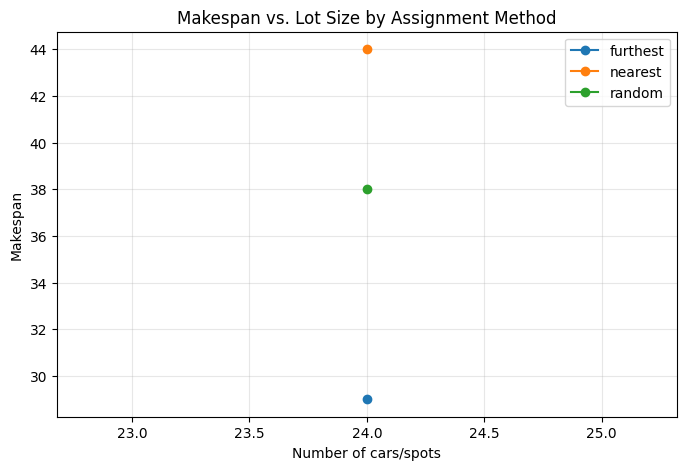

In [9]:
plot_metric_by_method(
    plot_df,
    metric="makespan",
    ylabel="Makespan",
    title="Makespan vs. Lot Size by Assignment Method",
)


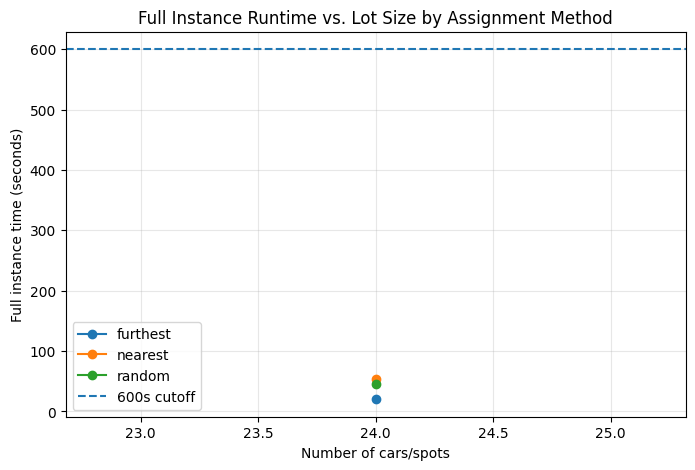

In [10]:
plot_metric_by_method(
    plot_df,
    metric="wall_runtime",
    ylabel="Full instance time (seconds)",
    title="Full Instance Runtime vs. Lot Size by Assignment Method",
    cutoff_line=INSTANCE_TIME_LIMIT_SECONDS,
)


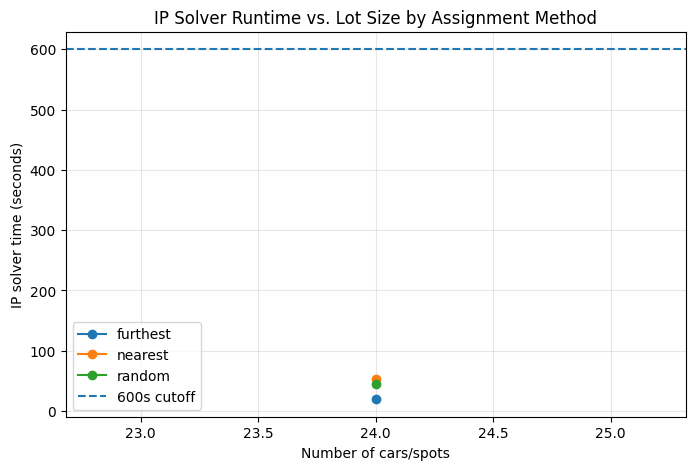

In [11]:
plot_metric_by_method(
    plot_df,
    metric="solver_runtime",
    ylabel="IP solver time (seconds)",
    title="IP Solver Runtime vs. Lot Size by Assignment Method",
    cutoff_line=INSTANCE_TIME_LIMIT_SECONDS,
)


## 8. Stacked comparison plot

This creates one figure with three stacked plots using only completed, non-cutoff rows:

1. Makespan
2. Full instance time
3. IP solver time


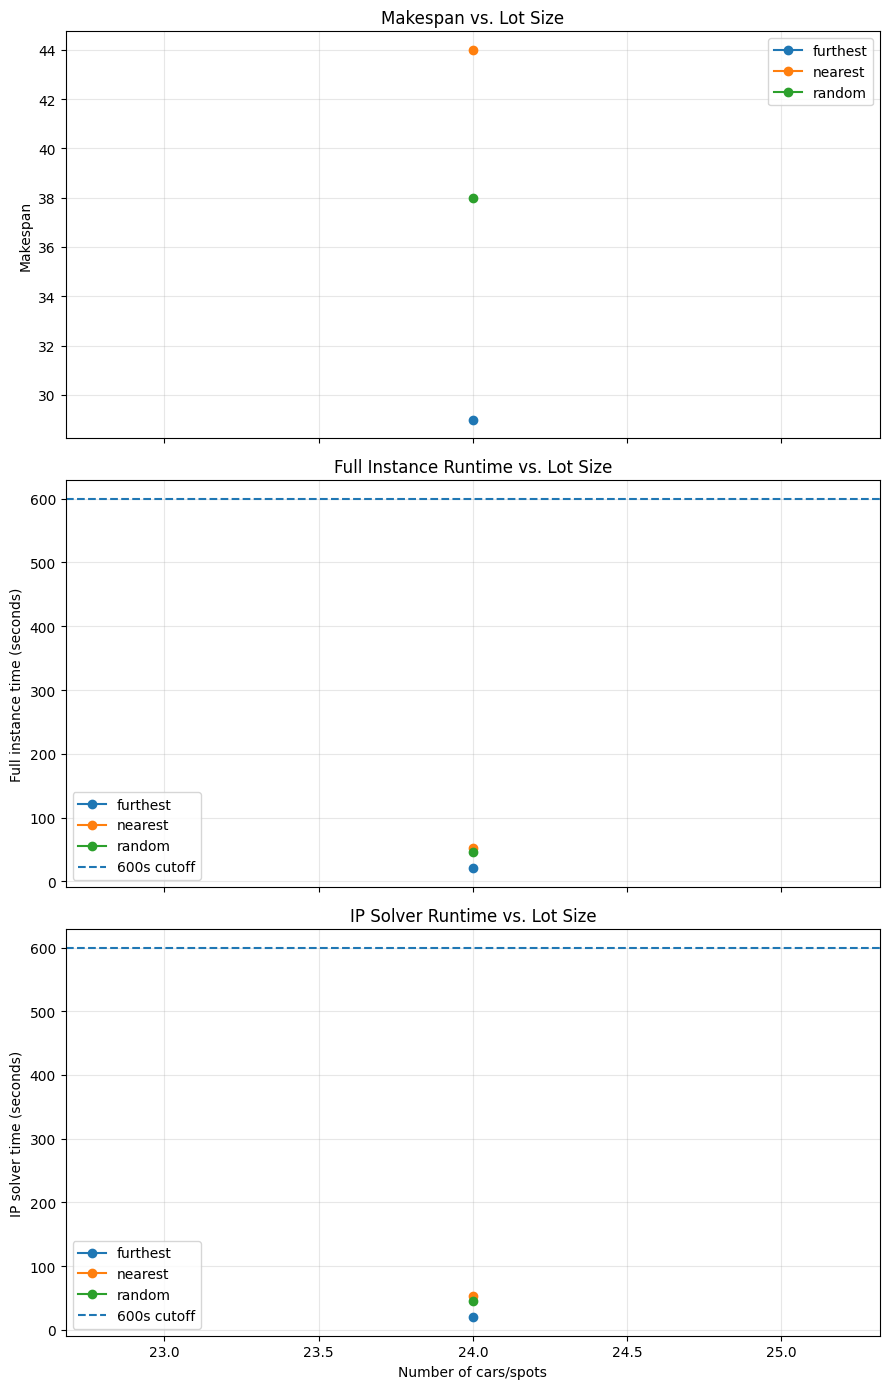

In [12]:
if plot_df.empty:
    print("Skipping stacked plot because no graphable rows are available.")
else:
    fig, axes = plt.subplots(3, 1, figsize=(9, 14), sharex=True)

    plot_specs = [
        ("makespan", "Makespan", "Makespan vs. Lot Size"),
        ("wall_runtime", "Full instance time (seconds)", "Full Instance Runtime vs. Lot Size"),
        ("solver_runtime", "IP solver time (seconds)", "IP Solver Runtime vs. Lot Size"),
    ]

    for ax, (metric, ylabel, title) in zip(axes, plot_specs):
        for method, group in plot_df.groupby("assignment_method"):
            group = group.sort_values("num_spots")
            if group.empty:
                continue

            ax.plot(
                group["num_spots"],
                group[metric],
                marker="o",
                label=method,
            )

        if metric in ["wall_runtime", "solver_runtime"]:
            ax.axhline(
                INSTANCE_TIME_LIMIT_SECONDS,
                linestyle="--",
                label=f"{INSTANCE_TIME_LIMIT_SECONDS}s cutoff",
            )

        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.grid(True, alpha=0.3)
        ax.legend()

    axes[-1].set_xlabel("Number of cars/spots")

    plt.tight_layout()
    plt.show()


## 9. Save results

Both files are useful:

- `assignment_method_scaling_results_queued_fifo_fixed.csv` contains every attempted row.
- `assignment_method_scaling_plot_data_queued_fifo_fixed.csv` contains only rows that appear in the graphs.


In [13]:
results_df.to_csv("assignment_method_scaling_results_queued_fifo_fixed.csv", index=False)
plot_df.to_csv("assignment_method_scaling_plot_data_queued_fifo_fixed.csv", index=False)

results_df


,num_rows,num_spots,num_cars,assignment_method,is_graphable,status_code,status,solver_runtime,wall_runtime,num_vars,num_constraints,time_horizon,has_solution,makespan,avg_wait_time,total_wait_time,max_wait_time,mip_gap
0,8,24,24,random,True,2,OPTIMAL,44.838,45.573711,38363,46156,131,True,38,6.625000,159.0,16.0,0.000000
1,12,40,40,random,False,9,INSTANCE_TIMEOUT,597.934,600.351410,135519,153144,191,True,95,20.525000,821.0,62.0,0.526316
2,8,24,24,nearest,True,2,OPTIMAL,52.384,53.003836,36997,43844,128,True,44,9.125000,219.0,19.0,0.000000
3,12,40,40,nearest,False,9,INSTANCE_TIMEOUT,597.982,600.213483,120621,136812,188,True,92,31.275000,1251.0,55.0,0.456522
4,8,24,24,furthest,True,2,OPTIMAL,19.601,20.334206,36997,43844,128,True,29,5.208333,125.0,10.0,0.000000
5,12,40,40,furthest,False,9,INSTANCE_TIMEOUT,598.077,600.299739,120621,136812,188,True,72,18.675000,747.0,44.0,0.513889
